In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.set_printoptions(precision=2, suppress=True)

## Generating synthetic data sets

In [74]:
from sklearn.datasets import make_blobs

In [75]:
X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)

X.shape
y.shape

(100, 2)

(100,)

In [76]:
X[:5]
y[:5]

array([[-7.73, -8.39],
       [ 5.45,  0.74],
       [-2.98,  9.56],
       [ 6.04,  0.57],
       [-6.52, -6.32]])

array([2, 1, 0, 1, 2])

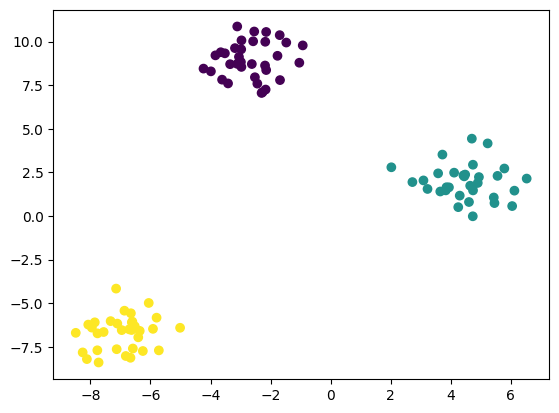

In [77]:
_ = plt.scatter(X[:, 0], X[:, 1], c=y)

## Generating linearly non-separable data (circle)

In [78]:
from sklearn.datasets import make_circles

In [79]:
X, y = make_circles(n_samples=100, noise=0.02, random_state=42)
X.shape
y.shape

(100, 2)

(100,)

In [80]:
X[:5]
y[:5]

array([[-0.42, -0.69],
       [ 0.75,  0.32],
       [-0.64,  0.48],
       [ 0.79, -0.59],
       [ 0.76, -0.71]])

array([1, 1, 1, 0, 0])

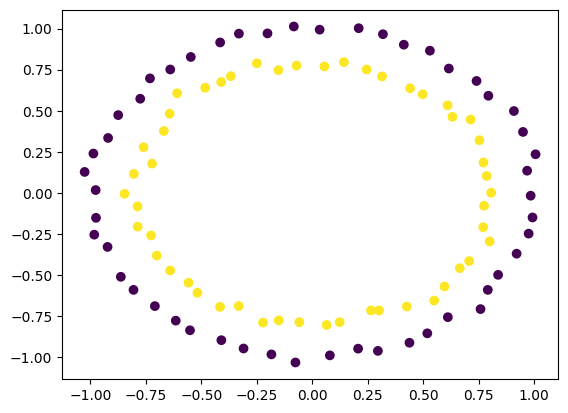

In [81]:
_ = plt.scatter(X[:, 0], X[:, 1], c=y)

## Imputation: filling missing values

In [82]:
from sklearn.impute import SimpleImputer

In [83]:
X = [
    [30, 1000],
    [10, np.nan],
    [np.nan, 7000],
    [40, 3000],
]

imputer = SimpleImputer(strategy='mean')
imputer.fit(X)
imputer.transform(X)

SimpleImputer()

array([[  30.  , 1000.  ],
       [  10.  , 3666.67],
       [  26.67, 7000.  ],
       [  40.  , 3000.  ]])

In [84]:
imputer.transform([
    [np.nan, 4000],
    [60, np.nan],
])

array([[  26.67, 4000.  ],
       [  60.  , 3666.67]])

In [85]:
imp = SimpleImputer(missing_values=np . nan, strategy='median')
X = [[4, 1], [np.nan, 5], [8, 0]]
imp.fit_transform(X)

array([[4., 1.],
       [6., 5.],
       [8., 0.]])

### Handling a messy data

In [86]:
data = {
    'Roll': [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
    'Age': [30, 0, 27, 30, 25, np.nan, 22, 28, np.nan, 35],
    'Country': ['USA', 'France', 'China', '-', 'Sweden', 'UK', 'Japan', 'Brazil', '?', 'India'],
    'Course': ['?', 'Math', 'English', 'NaN', 'Science', 'NULL', 'History', 'Art', '-', 'Math'],
    'Score': [15, 9999, 78, 22, 65, 48, 85, 90, -1, 55],
    'Result': ['F', 'Pass', 'NA', 'Fail', 'Unknown', 'Pass', 'Pass', 'F', 'Pass', 'NaN']
}

df = pd.DataFrame(data)
df

,Roll,Age,Country,Course,Score,Result
0,1001,30.0,USA,?,15,F
1,1002,0.0,France,Math,9999,Pass
2,1003,27.0,China,English,78,NA
3,1004,30.0,-,NaN,22,Fail
4,1005,25.0,Sweden,Science,65,Unknown
5,1006,NaN,UK,NULL,48,Pass
6,1007,22.0,Japan,History,85,Pass
7,1008,28.0,Brazil,Art,90,F
8,1009,NaN,?,-,-1,Pass
9,1010,35.0,India,Math,55,NaN


In [87]:
df.isnull().sum()

Roll       0
Age        2
Country    0
Course     0
Score      0
Result     0
dtype: int64

In [88]:
missing_markers = ['-', '?', 'Unknown', 'NULL', 'NA', 'NaN']

df = df.replace(missing_markers, np.nan)
df.isnull().sum()

Roll       0
Age        2
Country    2
Course     4
Score      0
Result     3
dtype: int64

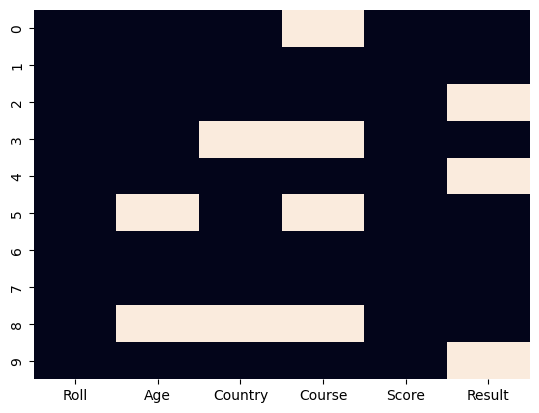

In [89]:
_ = sns.heatmap(df.isnull(), cbar=False)

## Categorical transforms
### One hot encoding

In [90]:
data = {
    'ID': range(1, 11),
    'Score': [85, 70, 92, 65, 88, 75, 80, 95, 60, 77],
    'Country': ['USA', 'India', 'UK', 'Canada', 'USA', 'India', 'UK', 'Canada', 'USA', 'India']
}

df = pd.DataFrame(data)
df.head()

,ID,Score,Country
0,1,85,USA
1,2,70,India
2,3,92,UK
3,4,65,Canada
4,5,88,USA


In [91]:
pd.get_dummies(df, columns=['Country'])

,ID,Score,Country_Canada,Country_India,Country_UK,Country_USA
0,1,85,False,False,False,True
1,2,70,False,True,False,False
2,3,92,False,False,True,False
3,4,65,True,False,False,False
4,5,88,False,False,False,True
5,6,75,False,True,False,False
6,7,80,False,False,True,False
7,8,95,True,False,False,False
8,9,60,False,False,False,True
9,10,77,False,True,False,False


In [92]:
from sklearn.preprocessing import LabelEncoder

In [93]:
le = LabelEncoder()
df_copy = df.copy()
df_copy['Country'] = le.fit_transform(df['Country'])

df_copy.head()
le.classes_

,ID,Score,Country
0,1,85,3
1,2,70,1
2,3,92,2
3,4,65,0
4,5,88,3


array(['Canada', 'India', 'UK', 'USA'], dtype=object)

### LabelBinarizer

In [94]:
from sklearn.preprocessing import LabelBinarizer

In [95]:
countries = ['UK', 'USA', 'India', 'USA']

lb = LabelBinarizer()
lb.fit_transform(countries)
lb.classes_

array([[0, 1, 0],
       [0, 0, 1],
       [1, 0, 0],
       [0, 0, 1]])

array(['India', 'UK', 'USA'], dtype='<U5')

### MultiLabelBinarizer

In [96]:
from sklearn.preprocessing import MultiLabelBinarizer

In [97]:
genres = [('Action', 'Comedy'),
          ('Action',),
          ('Action', 'Sci-Fi'),
          ('Drama', 'Action'),
          ('Comedy',),
          ('Sci-Fi',)]

mlb = MultiLabelBinarizer()
mlb.fit_transform(genres)
mlb.classes_

array([[1, 1, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 1],
       [1, 0, 1, 0],
       [0, 1, 0, 0],
       [0, 0, 0, 1]])

array(['Action', 'Comedy', 'Drama', 'Sci-Fi'], dtype=object)

###  OneHotEncoder

In [98]:
from sklearn.preprocessing import OneHotEncoder

In [99]:
X = np.array([
    ('apple', 'India', 100),
    ('banana', 'India', 90),
    ('litchi', 'India', 110),
    ('banana', 'India', 40),
    ('apple', 'UK', 120),
    ('litchi', 'UK',  160),])

ohe = OneHotEncoder(sparse_output=False)
ohe.fit_transform(X[:, :2])
ohe.get_feature_names_out(['fruit', 'country'])

array([[1., 0., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 0., 1.]])

array(['fruit_apple', 'fruit_banana', 'fruit_litchi', 'country_India',
       'country_UK'], dtype=object)

In [100]:
X = np.array([[4],
              [6],
              [4],
              [4],
              [6],
              [9],])

ohe = OneHotEncoder(sparse_output=False)
ohe.fit_transform(X)
ohe.get_feature_names_out(['cgpa'])

array([[1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

array(['cgpa_4', 'cgpa_6', 'cgpa_9'], dtype=object)

### Looking into activity questions

In [101]:
from sklearn.preprocessing import add_dummy_feature

imp = SimpleImputer(missing_values=np.nan, strategy='mean')
X = [[3, 8], [1, 4], [8, np.nan]]
add_dummy_feature(imp.fit_transform(X))

array([[1., 3., 8.],
       [1., 1., 4.],
       [1., 8., 6.]])

In [102]:
lb = LabelBinarizer()
lb.fit_transform(['yes', 'yes', 'no', 'yes'])

array([[1],
       [1],
       [0],
       [1]])

## Numerical transformations

In [103]:
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, StandardScaler

In [104]:
data = {
    'Salary': [50000, 80000, 120000, 45000, 95000, 110000, 60000, 75000, 130000, 52000],
    'Experience': [1, 5, 10, 0, 7, 9, 2, 4, 12, 1]
}

df = pd.DataFrame(data)
df.head()

,Salary,Experience
0,50000,1
1,80000,5
2,120000,10
3,45000,0
4,95000,7


In [105]:
# Scales in range [0, 1]
scalar = MinMaxScaler()
df_scaled = pd.DataFrame(scalar.fit_transform(df), columns=df.columns)
df_scaled.head()
df_scaled.min()
df_scaled.max()

,Salary,Experience
0,0.058824,0.083333
1,0.411765,0.416667
2,0.882353,0.833333
3,0.000000,0.000000
4,0.588235,0.583333


Salary        0.0
Experience    0.0
dtype: float64

Salary        1.0
Experience    1.0
dtype: float64

In [106]:
# Scales in range [-1, 1]
scalar = MaxAbsScaler()
df_scaled = pd.DataFrame(scalar.fit_transform(df), columns=df.columns)
df_scaled.head()

,Salary,Experience
0,0.384615,0.083333
1,0.615385,0.416667
2,0.923077,0.833333
3,0.346154,0.000000
4,0.730769,0.583333


In [107]:
# Scales such mean = 0, standard deviation = 1
scalar = StandardScaler()
df_scaled = pd.DataFrame(scalar.fit_transform(df), columns=df.columns)
df_scaled.head()
df_scaled.mean()
df_scaled.std()

,Salary,Experience
0,-1.085381,-1.022129
1,-0.058207,-0.024930
2,1.311359,1.221569
3,-1.256577,-1.271429
4,0.455381,0.473670


Salary       -2.220446e-17
Experience    6.661338e-17
dtype: float64

Salary        1.054093
Experience    1.054093
dtype: float64

In [108]:
Y = [[2], [8], [-4]]
mas = MaxAbsScaler()
print(mas.fit_transform(Y))

[[ 0.25]
 [ 1.  ]
 [-0.5 ]]


### Function transformation

In [109]:
np.log(np.e**2)
np.log2(16)
np.log10(1000)

np.float64(2.0)

np.float64(4.0)

np.float64(3.0)

In [110]:
np.log(0)
np.log1p(0)  # ln(1+x)

C:\Users\vidha\AppData\Local\Temp\ipykernel_9200\1490665351.py:1: RuntimeWarning: divide by zero encountered in log
  np.log(0)


np.float64(-inf)

np.float64(0.0)

In [111]:
from sklearn.preprocessing import FunctionTransformer

In [112]:
df = pd.DataFrame({'Revenue': [100, 200, 5000, 10000]})

log_transformer = FunctionTransformer(np.log1p)
log_transformer.fit_transform(df)

,Revenue
0,4.615121
1,5.303305
2,8.517393
3,9.210440


In [113]:
X = [
    [10, 20],
    [10, 30],
    [20, 30],
    [40, 50],
]
transformer = FunctionTransformer(np.mean)
transformer.fit_transform(X)
np.mean(X)
np.sum(X) / 8

np.float64(26.25)

np.float64(26.25)

np.float64(26.25)

### Generating polynomial features

In [114]:
data = {
    'x1': [1, 2, 3, 4, 5],
    'x2': [2, 4, 1, 3, 2]
}

df = pd.DataFrame(data)
df

,x1,x2
0,1,2
1,2,4
2,3,1
3,4,3
4,5,2


In [115]:
from sklearn.preprocessing import PolynomialFeatures

In [116]:
poly2 = PolynomialFeatures(degree=2)
pd.DataFrame(poly2.fit_transform(df), columns=poly2.get_feature_names_out())

,1,x1,x2,x1^2,x1 x2,x2^2
0,1.0,1.0,2.0,1.0,2.0,4.0
1,1.0,2.0,4.0,4.0,8.0,16.0
2,1.0,3.0,1.0,9.0,3.0,1.0
3,1.0,4.0,3.0,16.0,12.0,9.0
4,1.0,5.0,2.0,25.0,10.0,4.0


In [117]:
poly3 = PolynomialFeatures(degree=3)
pd.DataFrame(poly3.fit_transform(df), columns=poly3.get_feature_names_out())

,1,x1,x2,x1^2,x1 x2,x2^2,x1^3,x1^2 x2,x1 x2^2,x2^3
0,1.0,1.0,2.0,1.0,2.0,4.0,1.0,2.0,4.0,8.0
1,1.0,2.0,4.0,4.0,8.0,16.0,8.0,16.0,32.0,64.0
2,1.0,3.0,1.0,9.0,3.0,1.0,27.0,9.0,3.0,1.0
3,1.0,4.0,3.0,16.0,12.0,9.0,64.0,48.0,36.0,27.0
4,1.0,5.0,2.0,25.0,10.0,4.0,125.0,50.0,20.0,8.0


### KBinsDiscretizer

In [118]:
from sklearn.preprocessing import KBinsDiscretizer

In [119]:
df = pd.DataFrame([10, 20, 10, 30, 20, 40, 50, 60, 80, 30], columns=['Age'])
df.head()

,Age
0,10
1,20
2,10
3,30
4,20


array([33.33, 56.67])

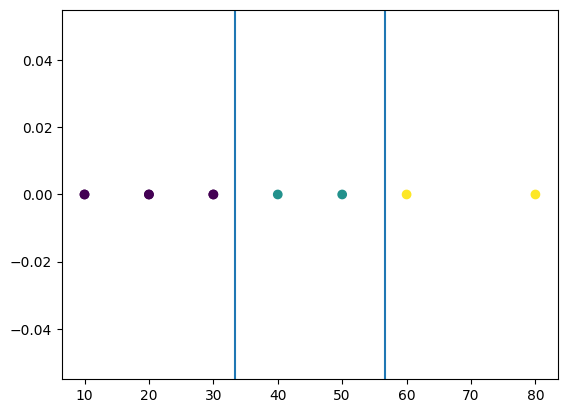

In [120]:
kbd = KBinsDiscretizer(n_bins=3, strategy='uniform', encode='ordinal')
bins = kbd.fit_transform(df)

age_min = df['Age'].min()
age_max = df['Age'].max()
cw = (age_max - age_min) / 3
boundaries = np.arange(age_min, age_max, cw)[1:]
boundaries

_ = plt.scatter(df['Age'], [0]*len(df), c=bins)
_ = plt.axvline(boundaries[0])
_ = plt.axvline(boundaries[1])

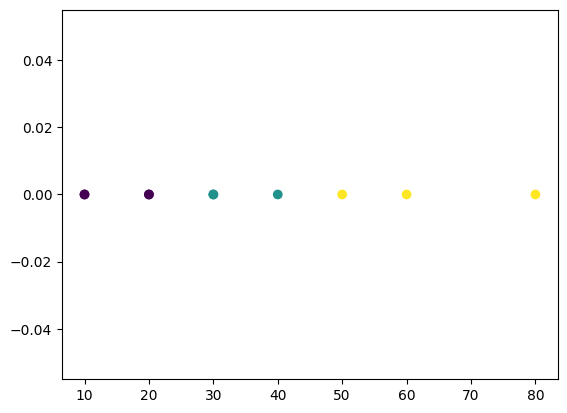

In [121]:
kbd = KBinsDiscretizer(n_bins=3, strategy='quantile', encode='ordinal')
bins = kbd.fit_transform(df)

_ = plt.scatter(df['Age'], [0]*len(df), c=bins)

## Outliers

In [122]:
data = {
    'Annual_Income_k': [45, 52, 48, 60, 55, 300, 50, 47, 58, 1000],  # Outliers: 300 and 1000
    'Property_Age': [5, 2, 8, 4, 1, 150, 6, 3, 9, 250]               # Outliers: 150 and 250
}

df = pd.DataFrame(data)
df

,Annual_Income_k,Property_Age
0,45,5
1,52,2
2,48,8
3,60,4
4,55,1
5,300,150
6,50,6
7,47,3
8,58,9
9,1000,250


In [123]:
df.describe()

,Annual_Income_k,Property_Age
count,10.000000,10.000000
mean,171.500000,43.800000
std,301.405688,85.668353
min,45.000000,1.000000
25%,48.500000,3.250000
50%,53.500000,5.500000
75%,59.500000,8.750000
max,1000.000000,250.000000


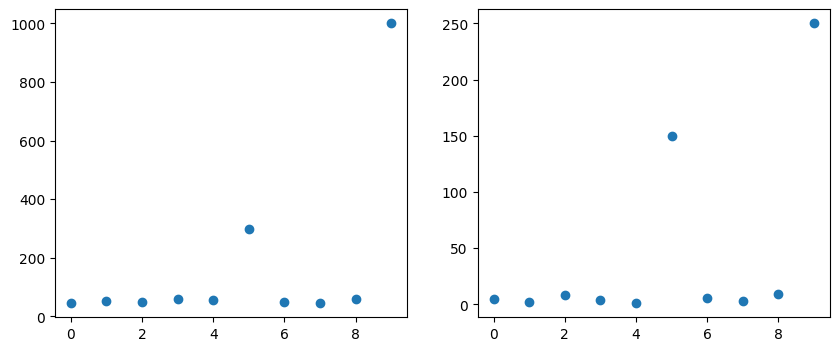

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
_ = axes[0].scatter(df.index, df['Annual_Income_k'])
_ = axes[1].scatter(df.index, df['Property_Age'])

In [125]:
data = np.array([20, 10, 30, 40, 50, 60, 500, -40])

q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q1 + 1.5 * iqr

filtered_data = data[(data >= lower_bound) & (data <= upper_bound)]

print(f'iqr: {iqr}')
print(f'Lower bound: {lower_bound}, Upper bound: {upper_bound}')
print(f'Filtered data: {filtered_data}')

iqr: 35.0
Lower bound: -35.0, Upper bound: 70.0
Filtered data: [20 10 30 40 50 60]


## Feature selection

### Filter based feature selection

In [126]:
from sklearn.datasets import load_digits

In [127]:
X, y = load_digits(return_X_y=True)
X.shape
y.shape

(1797, 64)

(1797,)

In [128]:
from sklearn.feature_selection import GenericUnivariateSelect, chi2

In [129]:
selector = GenericUnivariateSelect(score_func=chi2, mode='k_best', param=20)
X_selector = selector.fit_transform(X, y)
X_selector.shape

(1797, 20)

In [130]:
selected_indices = selector.get_support(indices=True)
df = pd.DataFrame(X)

selected_indices
df[selected_indices].head(1)

array([ 5,  6, 13, 19, 20, 21, 26, 28, 30, 33, 34, 41, 42, 43, 44, 46, 54,
       58, 61, 62])

,5,6,13,19,20,21,26,28,30,33,34,41,42,43,44,46,54,58,61,62
0,1.0,0.0,15.0,2.0,0.0,11.0,12.0,0.0,8.0,5.0,8.0,4.0,11.0,0.0,1.0,7.0,0.0,6.0,0.0,0.0


In [131]:
from sklearn.feature_selection import VarianceThreshold

In [132]:
X = np.array([
    [0, 2, 0, 1],
    [0, 1, 4, 1],
    [0, 1, 1, 1],
    [0, 3, 5, 1],
    [0, 2, 2, 1]
])
X.shape

(5, 4)

In [133]:
selector = VarianceThreshold(threshold=0.0)
X_selector = selector.fit_transform(X)
X_selector.shape

(5, 2)

In [134]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, f_classif

In [135]:
X, y = load_breast_cancer(return_X_y=True)
X.shape
y.shape

(569, 30)

(569,)

In [136]:
selector = SelectKBest(score_func=f_classif, k=5)
X_selector = selector.fit_transform(X, y)
X_selector.shape

(569, 5)

In [137]:
selected_indices = selector.get_support(indices=True)
selected_indices

for index in selected_indices:
  print(f"Feature {index}: {selector.scores_[index]:.2f}")

array([ 2,  7, 20, 22, 27])

Feature 2: 697.24
Feature 7: 861.68
Feature 20: 860.78
Feature 22: 897.94
Feature 27: 964.39


### Heterogeneous feature transformations

In [138]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder

In [144]:
X = np.array([[1, 'yes'], [2, 'no'], [3, 'yes'], [4, 'no']])

ct = ColumnTransformer([
    ('min-max Scalar', MinMaxScaler(), [0]),
    ('Ordinal Encoder', OrdinalEncoder(), [1])
])

ct.fit_transform(X)

array([[0.  , 1.  ],
       [0.33, 0.  ],
       [0.67, 1.  ],
       [1.  , 0.  ]])

In [146]:
X = np.array([[1, 'yes'], [2, 'no'], [3, 'no']])

ct = ColumnTransformer([
    ('min-max Scalar', MinMaxScaler(), [0]),
    ('pass', 'passthrough', [0]),
    ('Ordinal Encoder', OrdinalEncoder(), [1])
])

ct.fit_transform(X)

array([['0.0', '1', '1.0'],
       ['0.5', '2', '0.0'],
       ['1.0', '3', '0.0']], dtype='<U32')